In [2]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sqlite3

conn = sqlite3.connect("ecommerce_customer.db")
cursor = conn.cursor()

In [5]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"

tables = {
    "customers": "customers.csv",
    "transactions": "transactions.csv",
    "marketing_spend":"marketing_spend.csv",
    "returns":"returns.csv"
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded customers: 8000 rows
Loaded transactions: 100000 rows
Loaded marketing_spend: 216 rows
Loaded returns: 7126 rows


In [6]:
conn = sqlite3.connect('ecommerce_customer.db')

sql_query = """SELECT *
FROM customers
"""
customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [7]:
customers_df.head()

,customer_id,first_name,last_name,country,currency,age,gender,registration_date,is_premium,email_verified,email
0,CUST00001,Laura,Brown,UK,GBP,21,F,2020-10-12,0,1,laura.brown0001@email.com
1,CUST00002,Claire,Brown,Australia,AUD,47,M,2020-07-13,1,1,claire.brown0002@email.com
2,CUST00003,Thomas,Allen,Canada,CAD,68,M,2020-06-04,0,1,thomas.allen0003@email.com
3,CUST00004,William,Jackson,France,EUR,59,M,2020-12-12,0,0,william.jackson0004@email.com
4,CUST00005,Nina,Mueller,USA,USD,56,F,2021-10-24,0,1,nina.mueller0005@email.com


In [8]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        16000 non-null  str  
 1   first_name         16000 non-null  str  
 2   last_name          16000 non-null  str  
 3   country            16000 non-null  str  
 4   currency           16000 non-null  str  
 5   age                16000 non-null  int64
 6   gender             16000 non-null  str  
 7   registration_date  16000 non-null  str  
 8   is_premium         16000 non-null  int64
 9   email_verified     16000 non-null  int64
 10  email              16000 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.3 MB


In [36]:
sql_query = """
SELECT 
    c.customer_id,
    (c.first_name || ' ' || c.last_name) AS full_name,
    c.age,
    c.currency,
    -- Recency: Days between the most recent transaction in the dataset and the customer's last purchase
    CAST(julianday((SELECT MAX(date) FROM transactions)) - julianday(MAX(t.date)) AS INT) AS recency,
    -- Frequency: Total number of transactions
    COUNT(t.profit_usd) AS frequency,
    -- Monetary: Total profit generated by the customer
    SUM(t.profit_usd) AS monetary

FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name, c.age, c.currency
ORDER BY recency,frequency, monetary DESC
"""
rfm_df = pd.read_sql_query(sql_query, conn)


In [77]:

# Assign scores from 1 to 5 (Note: lower recency days mean a higher/better recency score)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine into a final RFM Score string
rfm_df['RFM_Score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)


In [78]:
rfm_df.head()

,customer_id,full_name,age,currency,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
0,CUST07987,Robert Taylor,58,EUR,0,16,7168.28,5,1,4,514
1,CUST05425,John Walker,62,GBP,0,16,5432.88,5,1,3,513
2,CUST06807,Maria Smith,41,CAD,0,16,4871.16,5,1,3,513
3,CUST03316,Elena Thomas,71,EUR,0,16,3088.96,5,1,2,512
4,CUST02794,Sophie Mueller,59,USD,0,16,1994.72,5,1,1,511


In [79]:

# 1. Define the multi-conditional mapping function based on your scores
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    # Core logic mapping rules
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f == 1:
        return 'Promising New Buyers'  # Fits your 5-1-X customers perfectly
    elif r <= 2 and f >= 3:
        return 'At Risk / Can\'t Lose'
    elif r <= 2 and f <= 2:
        return 'Hibernating / Lost'
    else:
        return 'Needs Attention / About to Sleep'

# 2. Map the segments onto your current dataset
rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

# 3. View the final categorized layout
print(rfm_df[['full_name', 'RFM_Score', 'Segment']])


           full_name RFM_Score               Segment
0      Robert Taylor       514  Promising New Buyers
1        John Walker       513  Promising New Buyers
2        Maria Smith       513  Promising New Buyers
3       Elena Thomas       512  Promising New Buyers
4     Sophie Mueller       511  Promising New Buyers
...              ...       ...                   ...
7972     Laura Smith       111    Hibernating / Lost
7973      Luca Young       111    Hibernating / Lost
7974   Elena Jackson       111    Hibernating / Lost
7975    Claire Brown       111    Hibernating / Lost
7976     James Brown       111    Hibernating / Lost

[7977 rows x 3 columns]


/tmp/ipykernel_20484/644080148.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


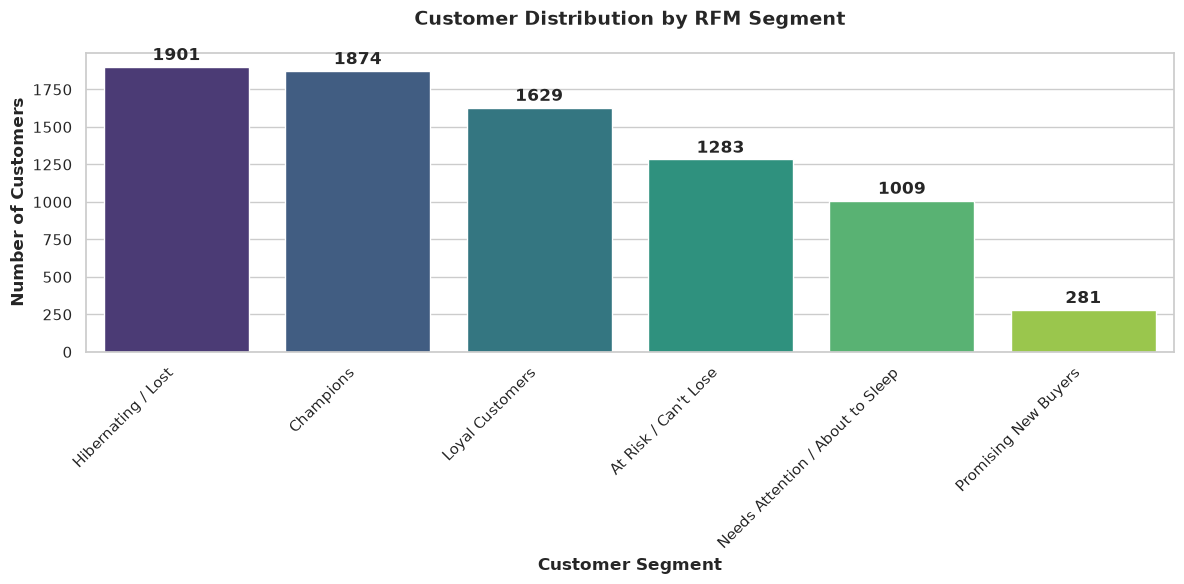

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the count plot
ax = sns.countplot(
    data=rfm_df, 
    x='Segment', 
    order=rfm_df['Segment'].value_counts().index, 
    palette='viridis'
)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold')

plt.title('Customer Distribution by RFM Segment', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [67]:
sql_query = """
SELECT 
    '2022' AS Year,
    (SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2022%' OR year_month LIKE '22%') AS Total_Marketing_Spend,
    (SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2022%' OR registration_date LIKE '%22' OR registration_date LIKE '22%') AS New_Customers_Acquired,
    ROUND((SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2022%' OR year_month LIKE '22%') / 
          CAST(NULLIF((SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2022%' OR registration_date LIKE '%22' OR registration_date LIKE '22%'), 0) AS REAL), 2) AS CAC

UNION ALL

SELECT 
    '2023' AS Year,
    (SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2023%' OR year_month LIKE '23%') AS Total_Marketing_Spend,
    (SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2023%' OR registration_date LIKE '%23' OR registration_date LIKE '23%') AS New_Customers_Acquired,
    ROUND((SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2023%' OR year_month LIKE '23%') / 
          CAST(NULLIF((SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2023%' OR registration_date LIKE '%23' OR registration_date LIKE '23%'), 0) AS REAL), 2) AS CAC

UNION ALL

SELECT 
    '2024' AS Year,
    (SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2024%' OR year_month LIKE '24%') AS Total_Marketing_Spend,
    (SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2024%' OR registration_date LIKE '%24' OR registration_date LIKE '24%') AS New_Customers_Acquired,
    ROUND((SELECT SUM(spend_usd) FROM marketing_spend WHERE year_month LIKE '2024%' OR year_month LIKE '24%') / 
          CAST(NULLIF((SELECT COUNT(customer_id) FROM customers WHERE registration_date LIKE '2024%' OR registration_date LIKE '%24' OR registration_date LIKE '24%'), 0) AS REAL), 2) AS CAC;
"""

new_customers_df = pd.read_sql_query(sql_query, conn)




In [68]:
new_customers_df.head()

,Year,Total_Marketing_Spend,New_Customers_Acquired,CAC
0,2022,2204256.60,566,3894.45
1,2023,2541437.36,478,5316.81
2,2024,2881492.20,500,5762.98


/tmp/ipykernel_20484/1852846665.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


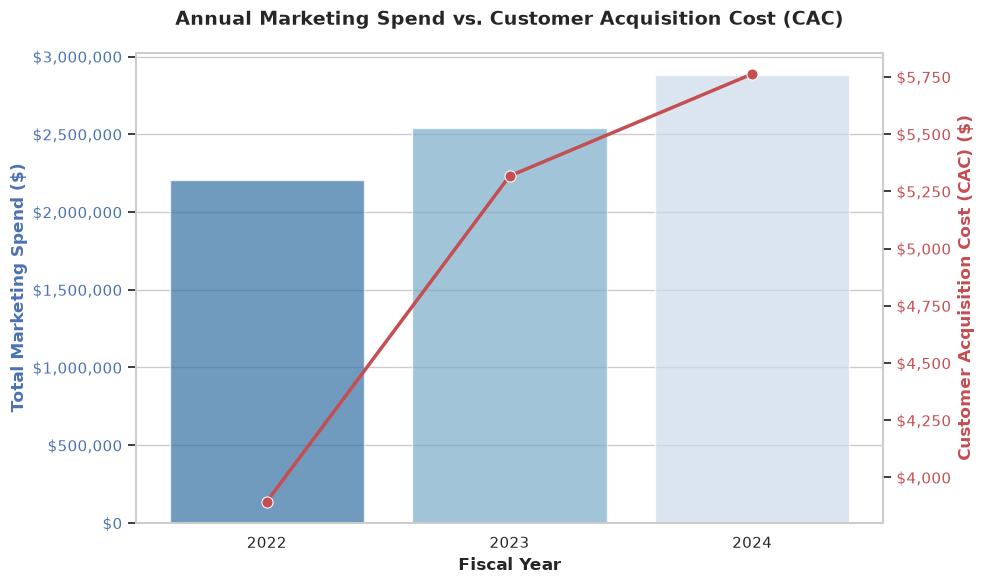

In [75]:
# Set high-quality styling defaults
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. Primary Y-Axis: Barplot for Total Marketing Spend
sns.barplot(
    data=new_customers_df, 
    x='Year', 
    y='Total_Marketing_Spend', 
    ax=ax1, 
    alpha=0.7, 
    palette='Blues_r'
)
ax1.set_ylabel('Total Marketing Spend ($)', color='b', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')
ax1.yaxis.set_major_formatter('${x:,.0f}')
ax1.set_xlabel('Fiscal Year', fontsize=12, fontweight='bold')

# 2. Secondary Y-Axis: Lineplot for CAC
ax2 = ax1.twinx()
sns.lineplot(
    data=new_customers_df, 
    x='Year', 
    y='CAC', 
    ax=ax2, 
    color='r', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    sort=False
)
ax2.set_ylabel('Customer Acquisition Cost (CAC) ($)', color='r', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='r')
ax2.yaxis.set_major_formatter('${x:,.0f}')
ax2.grid(False) # Turn off redundant secondary grid lines

plt.title('Annual Marketing Spend vs. Customer Acquisition Cost (CAC)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


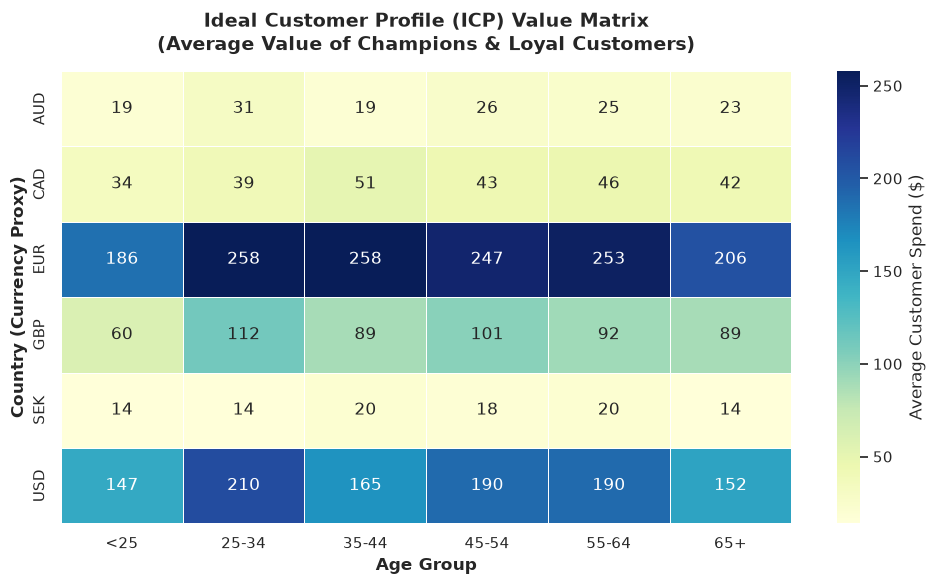

In [89]:

# 1. Filter for your top-tier ICP segments
icp_pool = rfm_df[rfm_df['Segment'].isin(['Champions', 'Loyal Customers'])].copy()

# 2. Bin age into clean demographic brackets
icp_pool['age_group'] = pd.cut(
    icp_pool['age'], 
    bins=[0, 25, 35, 45, 55, 65, 100], 
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

# 3. Create the pivot matrix (Average Monetary Spend per Demographic combination)
icp_matrix = icp_pool.pivot_table(
    index='currency', 
    columns='age_group', 
    values='customer_id', 
    aggfunc='count'
).fillna(0)

# 4. Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    icp_matrix, 
    annot=True, 
    fmt=",.0f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Average Customer Spend ($)'},
    linewidths=0.5
)

plt.title('Ideal Customer Profile (ICP) Value Matrix\n(Average Value of Champions & Loyal Customers)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12, fontweight='bold')
plt.ylabel('Country (Currency Proxy)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


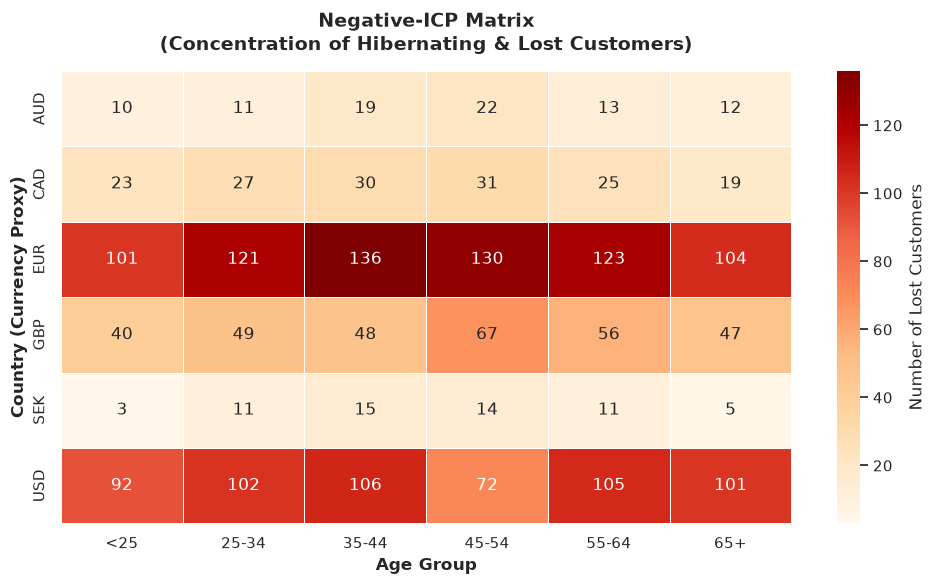

In [90]:
lost_pool = rfm_df[rfm_df['Segment'] == 'Hibernating / Lost'].copy()

# 2. Bin age into identical demographic brackets for direct comparison
lost_pool['age_group'] = pd.cut(
    lost_pool['age'], 
    bins=[0, 25, 35, 45, 55, 65, 100], 
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

# 3. Pivot the matrix using Customer Count to locate where churned users cluster
lost_matrix = lost_pool.pivot_table(
    index='currency', 
    columns='age_group', 
    values='customer_id', 
    aggfunc='count'
).fillna(0)

# 4. Plot the Heatmap using an alarming warm color profile (Reds)
plt.figure(figsize=(10, 6))
sns.heatmap(
    lost_matrix, 
    annot=True, 
    fmt=".0f", 
    cmap="OrRd", 
    cbar_kws={'label': 'Number of Lost Customers'},
    linewidths=0.5
)

plt.title('Negative-ICP Matrix\n(Concentration of Hibernating & Lost Customers)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=12, fontweight='bold')
plt.ylabel('Country (Currency Proxy)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()